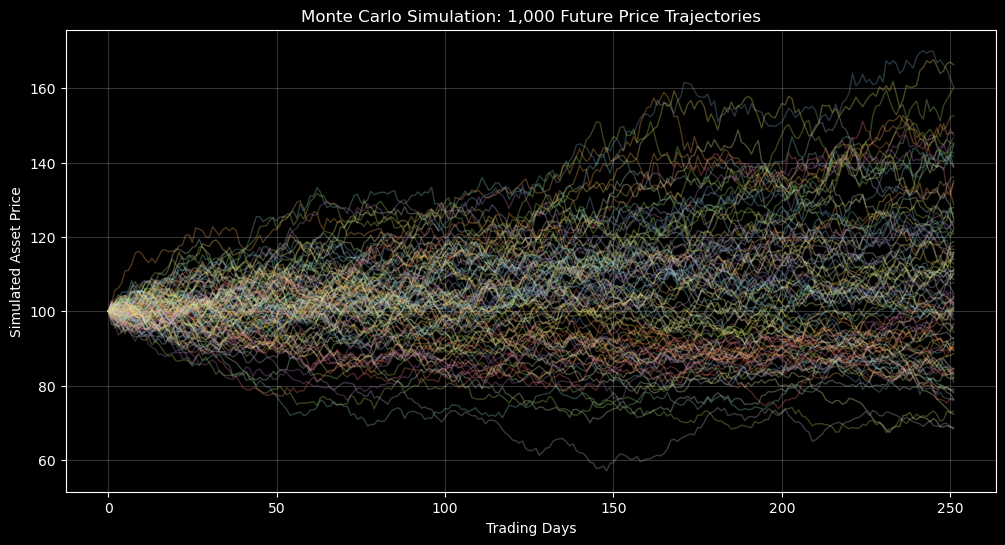

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Defining the Asset Parameters (Simulating a 1-Year Horizon)
S0 = 100.0      # Initial Price of the Asset
mu = 0.05       # Expected Annual Return (Drift of 5%)
sigma = 0.20    # Annual Volatility (20%)
T = 252         # Total Trading Days in a Year
simulations = 1000 # Number of alternate futures to generate

# 2. The Monte Carlo Engine (Geometric Brownian Motion)
np.random.seed(42) # Ensuring reproducibility for the portfolio

# Calculating the daily drift and random shocks for all 1000 simulations simultaneously
daily_returns = np.exp((mu - 0.5 * sigma**2) * (1/T) + sigma * np.sqrt(1/T) * np.random.normal(0, 1, (T, simulations)))

# Initializing the price paths matrix
price_paths = np.zeros_like(daily_returns)
price_paths[0] = S0

# Iterating through time to build the continuous price paths
for t in range(1, T):
    price_paths[t] = price_paths[t-1] * daily_returns[t]

# 3. Visualizing the Probability Cone
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

# Plotting a subset (the first 100 paths) to keep the visualization clean
plt.plot(price_paths[:, :100], alpha=0.3, linewidth=1)

plt.title('Monte Carlo Simulation: 1,000 Future Price Trajectories')
plt.xlabel('Trading Days')
plt.ylabel('Simulated Asset Price')
plt.grid(True, alpha=0.2)
plt.show()

In [3]:
# 4. Extracting the Probability Distribution from the final day (Row 251)
final_prices = price_paths[-1]

mean_final_price = np.mean(final_prices)
percentile_5th = np.percentile(final_prices, 5)
percentile_95th = np.percentile(final_prices, 95)

print("Monte Carlo Simulation Results (1,000 Iterations):")
print(f"Mean Expected Price: ${mean_final_price:.2f}")
print(f"90% Confidence Interval: The price will land between ${percentile_5th:.2f} and ${percentile_95th:.2f}")

Monte Carlo Simulation Results (1,000 Iterations):
Mean Expected Price: $105.16
90% Confidence Interval: The price will land between $73.93 and $144.07
